# NeuroVLM Quantitative Metrics — v2 (Semantic Metrics)

Evaluates both generative directions across three datasets.
BLEU / ROUGE have been replaced with meaning-aware metrics (see `why_not_bleu_rouge.md`).

| Direction | Datasets | Modes | Metrics |
|---|---|---|---|
| **Brain → Text** | Networks, PubMed, NeuroVault | Short & Long | **NeuroVLM Latent Sim** *(domain-specific)*, BERTScore F1, Semantic Cosine Sim |
| **Text → Brain** | Networks, PubMed, NeuroVault | — | Pearson *r*, Spearman ρ, PSNR, Dice (pct-90), Top-100 overlap |

**NeuroVLM Latent Similarity** encodes the generated text through NeuroVLM's own SPECTER
encoder + InfoNCE projection head, then measures cosine similarity to the original brain
embedding in the shared latent space — the most model-grounded evaluation available.

```
Prerequisites
pip install neurovlm[metrics,llm]
pip install bert-score sentence-transformers nltk scipy
# Ollama (fast path):
ollama pull qwen2.5:3b-instruct
```

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent, load_masker
from neurovlm.metrics import pearson_correlation, psnr

# Semantic text metrics
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util as st_util

# Spatial metrics
from scipy.stats import spearmanr

In [2]:
# ── LLM settings ──────────────────────────────────────────────────────────────
LLM_BACKEND = "ollama"               # "ollama" | "huggingface"
LLM_MODEL   = "qwen2.5:3b-instruct"  # Ollama: any pulled model

# ── BERTScore model ───────────────────────────────────────────────────────────
# Best for scientific text; swap for "distilbert-base-uncased" if OOM.
BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"

# ── Evaluation budget ─────────────────────────────────────────────────────────
MAX_B2T = 30   # samples per dataset for brain-to-text
MAX_T2B = 50   # samples per dataset for text-to-brain

# ── Retrieval settings ────────────────────────────────────────────────────────
B2T_TOP_K   = 5     # context rows passed to LLM
B2T_SIM_THR = 0.35  # cosine-similarity floor; relaxed if no rows pass
B2T_DATASETS = ["kg_mesh", "cogatlas"]  # retrieval corpora for brain-to-text

# ── Spatial metric settings ───────────────────────────────────────────────────
DICE_PCT   = 90    # percentile for thresholding activation maps
TOPK_K     = 100   # voxels for top-k overlap

In [3]:
nvlm   = NeuroVLM()
masker = load_masker()

print("Loading sentence transformer...")
_st_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Ready.")

Loading sentence transformer...
Ready.


---
## Dataset Preparation

In [4]:
# ── Networks dataset ──────────────────────────────────────────────────────────
SHORT_LABELS = {
    "Language":               "Language network supporting speech comprehension and production.",
    "Auditory":               "Auditory network for acoustic processing and speech encoding.",
    "Default Mode":           "Default mode network for self-referential thought and memory retrieval.",
    "Frontoparietal Control": "Frontoparietal control network for executive function and working memory.",
    "Attention":              "Dorsal attention network for goal-directed visuospatial attention.",
    "Visual":                 "Visual network for feature processing and object recognition.",
    "Motor":                  "Sensorimotor network for movement planning, initiation, and execution.",
    "Cingulo-Opercular":      "Salience network detecting salient events and driving performance monitoring.",
}

LONG_LABELS = {
    "Language": (
        "Language network (LAN; perisylvian language network; frontotemporal language system) [SEP] "
        "Primary regions: left inferior frontal gyrus (Broca's complex), posterior superior/middle temporal gyrus, "
        "temporoparietal junction/angular gyrus. "
        "Function: speech/text comprehension and production—semantics, syntax, phonology, and sentence-level integration."
    ),
    "Auditory": (
        "Auditory network (AUD; auditory cortex network) [SEP] "
        "Primary regions: Heschl's gyrus (primary auditory cortex), planum temporale, superior temporal gyrus. "
        "Function: acoustic feature analysis (pitch/timbre/timing), auditory scene analysis, early speech-sound encoding, "
        "and detection of salient sounds."
    ),
    "Default Mode": (
        "Default mode network (DMN; default network; default state network) [SEP] "
        "Primary regions: medial prefrontal cortex, posterior cingulate/precuneus, angular gyrus (lateral parietal). "
        "Function: internally oriented cognition—autobiographical/episodic memory, self-referential thought, "
        "future simulation, social inference, and narrative/semantic integration."
    ),
    "Frontoparietal Control": (
        "Frontoparietal control network (FPCN; frontoparietal network/FPN; central executive network/CEN) [SEP] "
        "Primary regions: dorsolateral/rostrolateral prefrontal cortex (middle frontal), posterior parietal cortex "
        "(inferior parietal/around intraparietal sulcus). "
        "Function: goal maintenance and flexible executive control—working memory, rule implementation, planning, "
        "and rapid task switching."
    ),
    "Attention": (
        "Dorsal attention network [SEP] "
        "Primary regions: intraparietal sulcus/superior parietal lobule and frontal eye fields. "
        "Function: goal-directed, voluntary control of visuospatial attention."
    ),
    "Visual": (
        "Visual network (VIS; occipital visual network) [SEP] "
        "Primary regions: calcarine cortex/V1 (cuneus/lingual), extrastriate occipital cortex, "
        "ventral occipitotemporal visual areas. "
        "Function: visual feature processing (form/color/motion), object/scene representations, "
        "and visuospatial analysis."
    ),
    "Motor": (
        "Motor network (motor/sensorimotor network; SMN) [SEP] "
        "Primary regions: primary motor cortex (precentral gyrus), supplementary motor area, premotor cortex; "
        "with primary somatosensory cortex (postcentral gyrus) for sensorimotor integration. "
        "Function: movement planning, initiation, and execution, plus proprioceptive/tactile feedback "
        "used to control actions and maintain body-state representations."
    ),
    "Cingulo-Opercular": (
        "Salience network (SN; cingulo-opercular network/CON; midcingulo-insular network) [SEP] "
        "Primary regions: anterior insula/frontal operculum, dorsal anterior cingulate/medial frontal cortex. "
        "Function: detects behaviorally relevant internal/external events (including interoceptive/affective signals), "
        "prioritizes attention and arousal, and drives performance monitoring and control adjustments "
        "(error/conflict/uncertainty)."
    ),
}

_LABEL_TO_DU = {
    "Language":               "LANG",
    "Auditory":               "AUD",
    "Default Mode":           "DN-A",
    "Frontoparietal Control": "FPN-A",
    "Attention":              "dATN-A",
    "Visual":                 "VIS-C",
    "Motor":                  "SMOT-A",
    "Cingulo-Opercular":      "CG-OP",
}

all_net_latents = load_latent("networks_neuro")
du = all_net_latents["Du"]

networks_data = {
    label: {
        "latent":   du[du_key],
        "short_gt": SHORT_LABELS[label],
        "long_gt":  LONG_LABELS[label],
    }
    for label, du_key in _LABEL_TO_DU.items()
    if du_key in du
}

print(f"Networks loaded: {list(networks_data.keys())}")

Networks loaded: ['Language', 'Auditory', 'Default Mode', 'Frontoparietal Control', 'Attention', 'Visual', 'Motor', 'Cingulo-Opercular']


In [5]:
# ── PubMed dataset ────────────────────────────────────────────────────────────
df_pubs = load_dataset("pubmed_text")
print("PubMed columns:", df_pubs.columns.tolist())
print(f"Total rows: {len(df_pubs)}")

if "split" in df_pubs.columns:
    df_test = df_pubs[df_pubs["split"] == "test"].reset_index(drop=True)
    print(f"Test split rows: {len(df_test)}")
else:
    print("WARNING: no 'split' column found — using full dataset as test proxy.")
    df_test = df_pubs.copy().reset_index(drop=True)

_pmid_col     = "pmid"        if "pmid"        in df_test.columns else df_test.columns[0]
_title_col    = "name"        if "name"        in df_test.columns else "title"
_abstract_col = "description" if "description" in df_test.columns else "abstract"

pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids)

mask = np.isin(pubmed_pmids, df_test[_pmid_col].values)
aligned_latents = pubmed_latents[mask]
aligned_pmids   = pubmed_pmids[mask]

pmid_to_row = df_test.set_index(_pmid_col)

pubmed_data = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    row      = pmid_to_row.loc[pmid]
    title    = str(row[_title_col])    if _title_col    in row.index else ""
    abstract = str(row[_abstract_col]) if _abstract_col in row.index else ""
    pubmed_data.append({
        "pmid":     pmid,
        "latent":   aligned_latents[i],
        "short_gt": title,
        "long_gt":  abstract,
    })

pubmed_data_b2t = pubmed_data[:MAX_B2T] if MAX_B2T else pubmed_data
pubmed_data_t2b = pubmed_data[:MAX_T2B] if MAX_T2B else pubmed_data

print(f"PubMed B2T samples: {len(pubmed_data_b2t)}")
print(f"PubMed T2B samples: {len(pubmed_data_t2b)}")

PubMed columns: ['pmid', 'pmcid', 'doi', 'name', 'description', 'train', 'test', 'val']
Total rows: 30826
PubMed B2T samples: 30
PubMed T2B samples: 50


In [6]:
# ── NeuroVault dataset ────────────────────────────────────────────────────────
df_nv      = load_dataset("neurovault_text")
df_nv_meta = load_dataset("neurovault_images_meta")
nv_latents = load_latent("neurovault_images")

print("NeuroVault pub columns:",  df_nv.columns.tolist())
print("NeuroVault meta columns:", df_nv_meta.columns.tolist())
print(f"NV latents shape: {nv_latents.shape}")

_doi_pub  = "doi"      if "doi"      in df_nv.columns      else df_nv.columns[0]
_doi_meta = "doi"      if "doi"      in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title"    if "title"    in df_nv.columns      else df_nv.columns[1]
_abs_nv   = "abstract" if "abstract" in df_nv.columns      else df_nv.columns[2]

neurovault_data = []
for _, pub_row in df_nv.iterrows():
    doi      = pub_row[_doi_pub]
    title    = str(pub_row[_title_nv])
    abstract = str(pub_row[_abs_nv])

    img_mask    = df_nv_meta[_doi_meta] == doi
    img_indices = np.where(img_mask.values)[0]

    if len(img_indices) == 0 or img_indices[0] >= len(nv_latents):
        continue

    img_idx = int(img_indices[0])
    neurovault_data.append({
        "doi":      doi,
        "latent":   nv_latents[img_idx],
        "short_gt": title,
        "long_gt":  abstract,
    })

neurovault_data_b2t = neurovault_data[:MAX_B2T] if MAX_B2T else neurovault_data
neurovault_data_t2b = neurovault_data[:MAX_T2B] if MAX_T2B else neurovault_data

print(f"NeuroVault B2T samples: {len(neurovault_data_b2t)}")
print(f"NeuroVault T2B samples: {len(neurovault_data_t2b)}")

NeuroVault pub columns: ['doi', 'title', 'abstract']
NeuroVault meta columns: ['Unnamed: 0', 'id', 'collection_id', 'contrast_definition', 'name', 'doi']
NV latents shape: torch.Size([3183, 384])
NeuroVault B2T samples: 30
NeuroVault T2B samples: 50


---
## Part A — Brain-to-Text (BERTScore, Semantic Sim, METEOR, NeuroVLM Latent Sim)

For each brain image we:
1. Retrieve the most similar text entries via contrastive similarity.
2. Generate with the LLM twice — once in **short** mode, once in **long** mode.
3. Compute BERTScore, sentence-level cosine similarity, and NeuroVLM latent similarity.

**NeuroVLM Latent Similarity** is the most meaningful metric here:
it encodes the generated text through NeuroVLM's own SPECTER + projection head
and computes cosine similarity against the original brain image embedding
in the shared latent space. A paraphrase that preserves meaning will score
as highly as a literal match — and the metric is grounded in the model's own
representation, not an external embedding space.

See `why_not_bleu_rouge.md` for the rationale for dropping BLEU / ROUGE.

In [7]:
import traceback


def _semantic_sim(gen: str, gt: str) -> float:
    emb1 = _st_model.encode(gen, convert_to_tensor=True)
    emb2 = _st_model.encode(gt,  convert_to_tensor=True)
    return float(st_util.cos_sim(emb1, emb2))


def _nvlm_latent_sim(brain_query_emb: torch.Tensor, generated: str) -> float:
    """Cosine similarity in NeuroVLM's shared latent space.

    brain_query_emb is the already-projected, L2-normalised brain embedding
    returned in TextSearchResult.query_embeddings.  We project the generated
    text through the same SPECTER + infonce projection head, normalise, and
    compute cosine similarity.
    """
    nvlm._ensure_projection_heads()
    with torch.no_grad():
        raw_emb = nvlm._encode_text(generated)                         # (1, 768)
        z_text  = nvlm._proj_head_text_infonce(raw_emb.to(nvlm.device)) # project
        z_text  = F.normalize(z_text, dim=-1).cpu()                    # normalise
    z_brain = brain_query_emb.cpu()
    if z_brain.dim() == 1:
        z_brain = z_brain.unsqueeze(0)
    return float(F.cosine_similarity(z_brain, z_text))


def _b2t_once(table, user_prompt, gt_text, max_tokens, brain_query_emb):
    """Generate one B2T response and compute all semantic metrics against gt_text."""
    generated = nvlm.generate_llm_response(
        backend=LLM_BACKEND,
        model_name=LLM_MODEL,
        table=table,
        user_prompt=user_prompt,
        max_new_tokens=max_tokens,
        verbose=False,
    )

    # BERTScore — contextual embedding overlap
    P, R, F1 = bert_score(
        cands=[generated],
        refs=[gt_text],
        lang="en",
        model_type=BERTSCORE_MODEL,
        verbose=False,
    )

    # Sentence embedding cosine similarity (generic)
    sem_sim = _semantic_sim(generated, gt_text)

    # NeuroVLM latent similarity — most domain-specific metric
    nvlm_sim = _nvlm_latent_sim(brain_query_emb, generated)

    return {
        "generated":  generated,
        "gt_text":    gt_text,
        "bert_p":     float(P[0]),
        "bert_r":     float(R[0]),
        "bert_f1":    float(F1[0]),
        "sem_sim":    sem_sim,
        "nvlm_sim":   nvlm_sim,
    }


def _format_context_summary(table):
    lines = []
    for _, row in table.iterrows():
        ds  = row.get("dataset", "?")
        ttl = str(row.get("title", "")).strip()
        sim = row.get("cosine_similarity", float("nan"))
        lines.append(f"  [{ds}] (sim={sim:.3f}) {ttl}")
    return "\n".join(lines)


def run_b2t(name, latent, short_gt, long_gt,
            short_prompt, long_prompt="",
            short_tokens=64, long_tokens=512):
    try:
        result    = nvlm.brain(latent).to_text(datasets=B2T_DATASETS)
        all_table = result.top_k(B2T_TOP_K)  # top-k per dataset
        table     = all_table[all_table["cosine_similarity"] > B2T_SIM_THR]
        if table.empty:
            table = all_table
        # globally rank across datasets and keep at most B2T_TOP_K
        if len(table) > B2T_TOP_K:
            table = table.nlargest(B2T_TOP_K, "cosine_similarity").reset_index(drop=True)

        context_summary  = _format_context_summary(table)
        brain_query_emb  = result.query_embeddings  # brain in shared latent space

        records = []
        for mode, prompt, gt, tokens in [
            ("short", short_prompt, short_gt, short_tokens),
            ("long",  long_prompt,  long_gt,  long_tokens),
        ]:
            rec = _b2t_once(table, prompt, gt, tokens, brain_query_emb)
            rec["name"]            = name
            rec["mode"]            = mode
            rec["context_summary"] = context_summary
            records.append(rec)

        return records

    except Exception as e:
        print(f"\n[B2T error] {name}: {type(e).__name__}: {e}")
        traceback.print_exc()
        return []


def show_b2t_texts(df, max_gt_chars=300, max_gen_chars=300):
    sep = "-" * 72
    prev_name = None
    for _, row in df.iterrows():
        name  = row.get("name", "?")
        mode  = row.get("mode", "?")
        gen   = str(row.get("generated",       "")).strip()
        gt    = str(row.get("gt_text",         "")).strip()
        ctx   = str(row.get("context_summary", "")).strip()
        bf1   = row.get("bert_f1",  float("nan"))
        sim   = row.get("sem_sim",  float("nan"))
        nvs   = row.get("nvlm_sim", float("nan"))

        print(sep)
        if name != prev_name and ctx:
            print(f"[{name}]  — retrieved context:")
            print(ctx)
            prev_name = name

        print(f"  mode={mode}   BERTScore-F1={bf1:.3f}  SemanticSim={sim:.3f}  "
              f"NeuroVLM-Sim={nvs:.3f}")
        print(f"  EXPECTED : {gt[:max_gt_chars]}{'…' if len(gt) > max_gt_chars else ''}")
        print(f"  GENERATED: {gen[:max_gen_chars]}{'…' if len(gen) > max_gen_chars else ''}")
    print(sep)


# ── Prompts ────────────────────────────────────────────────────────────────────
SHORT_PROMPT_GENERAL = (
    "Reply with a single concise sentence (10-20 words) naming the main "
    "cognitive function or brain network. Output only that sentence."
)

SHORT_PROMPT_PUBMED = (
    "Generate ONLY a paper title (6-12 words) for the neuroimaging study this "
    "brain activation pattern represents. Output the title only — no abstract, "
    "no explanation."
)

LONG_PROMPT = ""

### A.1 Networks

In [8]:
b2t_networks_records = []

for net_name, d in tqdm(networks_data.items(), desc="Networks B2T"):
    recs = run_b2t(
        name         = net_name,
        latent       = d["latent"],
        short_gt     = d["short_gt"],
        long_gt      = d["long_gt"],
        short_prompt = SHORT_PROMPT_GENERAL,
        long_prompt  = LONG_PROMPT,
    )
    b2t_networks_records.extend(recs)

print(f"\nRecords collected: {len(b2t_networks_records)}")

b2t_net_df = pd.DataFrame(b2t_networks_records)

if b2t_net_df.empty:
    print("No records — check the [B2T error] messages above.")
else:
    cols = ["name", "mode", "bert_f1", "bert_p", "bert_r", "sem_sim", "nvlm_sim"]
    display(b2t_net_df[cols].round(3))
    print()
    show_b2t_texts(b2t_net_df)

Networks B2T:   0%|          | 0/8 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.



Records collected: 16


,name,mode,bert_f1,bert_p,bert_r,sem_sim,nvlm_sim
0,Language,short,0.732,0.689,0.782,0.527,0.356
1,Language,long,0.558,0.518,0.604,0.642,0.366
2,Auditory,short,0.659,0.638,0.682,0.534,0.418
3,Auditory,long,0.556,0.491,0.641,0.729,0.401
4,Default Mode,short,0.803,0.782,0.826,0.824,0.365
5,Default Mode,long,0.478,0.401,0.592,0.810,0.388
6,Frontoparietal Control,short,0.746,0.748,0.744,0.602,0.312
7,Frontoparietal Control,long,0.536,0.478,0.610,0.647,0.319
8,Attention,short,0.796,0.776,0.817,0.836,0.359
9,Attention,long,0.472,0.388,0.600,0.632,0.398



------------------------------------------------------------------------
[Language]  — retrieved context:
[kg_mesh] (sim=0.426) language network
  [kg_mesh] (sim=0.413) language abilities
  [kg_mesh] (sim=0.408) expressive language
  [kg_mesh] (sim=0.402) superior temporal regions
  [kg_mesh] (sim=0.396) frontotemporal regions
  mode=short   BERTScore-F1=0.732  SemanticSim=0.527  NeuroVLM-Sim=0.356
  EXPECTED : Language network supporting speech comprehension and production.
  GENERATED: Language network supports expressive language through frontotemporal connectivity.
------------------------------------------------------------------------
  mode=long   BERTScore-F1=0.558  SemanticSim=0.642  NeuroVLM-Sim=0.366
  EXPECTED : Language network (LAN; perisylvian language network; frontotemporal language system) [SEP] Primary regions: left inferior frontal gyrus (Broca's complex), posterior superior/middle temporal gyrus, temporoparietal junction/angular gyrus. Function: speech/text compre

### A.2 PubMed

*Short* → LLM generates a title, evaluated against the real title.  
*Long* → LLM generates freely, evaluated against the abstract.

In [9]:
b2t_pubmed_records = []

for d in tqdm(pubmed_data_b2t, desc="PubMed B2T"):
    recs = run_b2t(
        name         = str(d["pmid"]),
        latent       = d["latent"],
        short_gt     = d["short_gt"],
        long_gt      = d["long_gt"],
        short_prompt = SHORT_PROMPT_PUBMED,
        long_prompt  = LONG_PROMPT,
        short_tokens = 48,
        long_tokens  = 512,
    )
    b2t_pubmed_records.extend(recs)

print(f"\nRecords collected: {len(b2t_pubmed_records)}")

b2t_pubmed_df = pd.DataFrame(b2t_pubmed_records)

if b2t_pubmed_df.empty:
    print("No records — check the [B2T error] messages above.")
else:
    display(b2t_pubmed_df.groupby("mode")[["bert_f1", "sem_sim", "nvlm_sim"]].mean().round(3))
    print()
    show_b2t_texts(b2t_pubmed_df)

PubMed B2T:   0%|          | 0/30 [00:00<?, ?it/s]


Records collected: 60


,bert_f1,sem_sim,nvlm_sim
mode,,,
long,0.488,0.412,0.298
short,0.585,0.353,0.310



------------------------------------------------------------------------
[1589767]  — retrieved context:
[cogatlas] (sim=0.479) word pronunciation
  [kg_mesh] (sim=0.469) native language
  [cogatlas] (sim=0.467) language processing
  [kg_mesh] (sim=0.463) language dominance
  [kg_mesh] (sim=0.463) natural speech
  mode=short   BERTScore-F1=0.597  SemanticSim=0.545  NeuroVLM-Sim=0.382
  EXPECTED : Lateralization of phonetic and pitch discrimination in speech processing.
  GENERATED: Language Dominance and Pronunciation Patterns in Bilinguals
------------------------------------------------------------------------
  mode=long   BERTScore-F1=0.483  SemanticSim=0.506  NeuroVLM-Sim=0.288
  EXPECTED : Cerebral activation was measured with positron emission tomography in ten human volunteers. The primary auditory cortex showed increased activity in response to noise bursts, whereas acoustically matched speech syllables activated secondary auditory cortices bilaterally. Instructions to make j

### A.3 NeuroVault

In [10]:
b2t_nv_records = []

for d in tqdm(neurovault_data_b2t, desc="NeuroVault B2T"):
    recs = run_b2t(
        name         = str(d["doi"]),
        latent       = d["latent"],
        short_gt     = d["short_gt"],
        long_gt      = d["long_gt"],
        short_prompt = SHORT_PROMPT_GENERAL,
        long_prompt  = LONG_PROMPT,
    )
    b2t_nv_records.extend(recs)

print(f"\nRecords collected: {len(b2t_nv_records)}")

b2t_nv_df = pd.DataFrame(b2t_nv_records)

if b2t_nv_df.empty:
    print("No records — check the [B2T error] messages above.")
else:
    display(b2t_nv_df.groupby("mode")[["bert_f1", "sem_sim", "nvlm_sim"]].mean().round(3))
    print()
    show_b2t_texts(b2t_nv_df)

NeuroVault B2T:   0%|          | 0/30 [00:00<?, ?it/s]


Records collected: 60


,bert_f1,sem_sim,nvlm_sim
mode,,,
long,0.509,0.371,0.323
short,0.576,0.286,0.324



------------------------------------------------------------------------
[10.1111/cdev.12630]  — retrieved context:
[kg_mesh] (sim=0.381) behaviorism
  [kg_mesh] (sim=0.369) mind-body therapies
  [kg_mesh] (sim=0.358) noninvasive ventilation
  [kg_mesh] (sim=0.357) idiopathic hypersomnia
  [kg_mesh] (sim=0.353) tetralogy of fallot
  mode=short   BERTScore-F1=0.587  SemanticSim=0.187  NeuroVLM-Sim=0.236
  EXPECTED : Neural Reactivity to Emotional Faces May Mediate the Relationship Between Childhood Empathy and Adolescent Prosocial Behavior
  GENERATED: Idiopathic hypersomnia affects sleep regulation networks in the brain.
------------------------------------------------------------------------
  mode=long   BERTScore-F1=0.499  SemanticSim=0.345  NeuroVLM-Sim=0.133
  EXPECTED : Reactivity to others' emotions not only can result in empathic concern (EC), an important motivator of prosocial behavior, but can also result in personal distress (PD), which may hinder prosocial behavior. Exami

### A.4 Brain-to-Text Summary

In [11]:
b2t_net_df["dataset"]    = "networks"
b2t_pubmed_df["dataset"] = "pubmed"
b2t_nv_df["dataset"]     = "neurovault"

b2t_all = pd.concat([b2t_net_df, b2t_pubmed_df, b2t_nv_df], ignore_index=True)

summary_b2t = (
    b2t_all
    .groupby(["dataset", "mode"])[["bert_f1", "bert_p", "bert_r", "sem_sim", "nvlm_sim"]]
    .agg(["mean", "std"])
    .round(3)
)

print("=== Brain-to-Text Summary (mean ± std) ===")
summary_b2t

=== Brain-to-Text Summary (mean ± std) ===


bert_f1        bert_p        bert_r        sem_sim         \
                    mean    std   mean    std   mean    std    mean    std   
dataset    mode                                                              
networks   long    0.520  0.032  0.459  0.044  0.601  0.026   0.676  0.065   
           short   0.722  0.072  0.708  0.069  0.738  0.078   0.604  0.184   
neurovault long    0.509  0.028  0.490  0.038  0.530  0.023   0.371  0.109   
           short   0.576  0.046  0.591  0.049  0.565  0.057   0.286  0.113   
pubmed     long    0.488  0.094  0.472  0.092  0.506  0.098   0.412  0.158   
           short   0.585  0.050  0.579  0.058  0.595  0.057   0.353  0.148   

                 nvlm_sim         
                     mean    std  
dataset    mode                   
networks   long     0.357  0.064  
           short    0.333  0.074  
neurovault long     0.323  0.088  
           short    0.324  0.115  
pubmed     long     0.298  0.086  
           short    0.310  0.082

### A.5 Recall@1 — Retrieval Rank

Given all N generated texts and N brain images in a dataset × mode group,
**Recall@1** measures the fraction of generated texts whose correct brain image
ranks #1 by `nvlm_sim` over all other brain images.

| Score | Interpretation |
|---|---|
| `1/N` | Chance level (random assignment) |
| `> 2/N` | Better than chance |
| `1.0` | Every generated text uniquely identifies its source brain |

In [17]:
def recall_at_1(df: pd.DataFrame) -> float:
    """
    Given N (brain, generated_text) pairs, compute the fraction where
    the brain's own generated text scores highest among all texts.
    Chance level = 1/N.
    """
    brain_embs = torch.stack([e.squeeze(0) for e in df["_brain_query_emb"].tolist()])
    nvlm._ensure_projection_heads()
    with torch.no_grad():
        texts    = df["generated"].tolist()
        raw_embs = torch.cat([nvlm._encode_text(t) for t in texts], dim=0)
        z_texts  = nvlm._proj_head_text_infonce(raw_embs.to(nvlm.device))
        z_texts  = F.normalize(z_texts, dim=-1).cpu()
    z_brains   = F.normalize(brain_embs, dim=-1)
    sim_matrix = z_brains @ z_texts.T
    ranks      = (sim_matrix > sim_matrix.diag().unsqueeze(1)).sum(dim=1)
    return float((ranks == 0).float().mean())


# ── Brain query embeddings (fast — no LLM call) ──────────────────────────
print("Computing Recall@1 ...")

brain_emb_cache = {}

def _get_brain_query_emb(name, latent):
    if name not in brain_emb_cache:
        r = nvlm.brain(latent).to_text(datasets=B2T_DATASETS)
        brain_emb_cache[name] = r.query_embeddings
    return brain_emb_cache[name]

_all_latents = {}
for k, d in networks_data.items():
    _all_latents[k] = d["latent"]
for d in pubmed_data_b2t:
    _all_latents[str(d["pmid"])] = d["latent"]
for d in neurovault_data_b2t:
    _all_latents[str(d["doi"])]  = d["latent"]

b2t_all["_brain_query_emb"] = b2t_all["name"].map(
    lambda n: _get_brain_query_emb(n, _all_latents[n])
)

# ── Recall@1 per dataset × mode ───────────────────────────────────────────
r1_rows = []
for (ds, mode), grp in b2t_all.groupby(["dataset", "mode"]):
    grp   = grp.reset_index(drop=True)
    n     = len(grp)
    r1    = recall_at_1(grp)
    chance = round(1 / n, 3)
    r1_rows.append({"dataset": ds, "mode": mode,
                    "N": n, "chance": chance, "recall@1": round(r1, 3)})

b2t_recall1 = pd.DataFrame(r1_rows).set_index(["dataset", "mode"])

print("\n=== Recall@1 ===")
print("  recall@1=1/N means chance; recall@1=1.0 means perfect")
display(b2t_recall1)

Computing Recall@1 ...

=== Recall@1 ===
  recall@1=1/N means chance; recall@1=1.0 means perfect


N  chance  recall@1
dataset    mode                       
networks   long    8   0.125     1.000
           short   8   0.125     1.000
neurovault long   30   0.033     0.800
           short  30   0.033     0.733
pubmed     long   30   0.033     0.700
           short  30   0.033     0.600

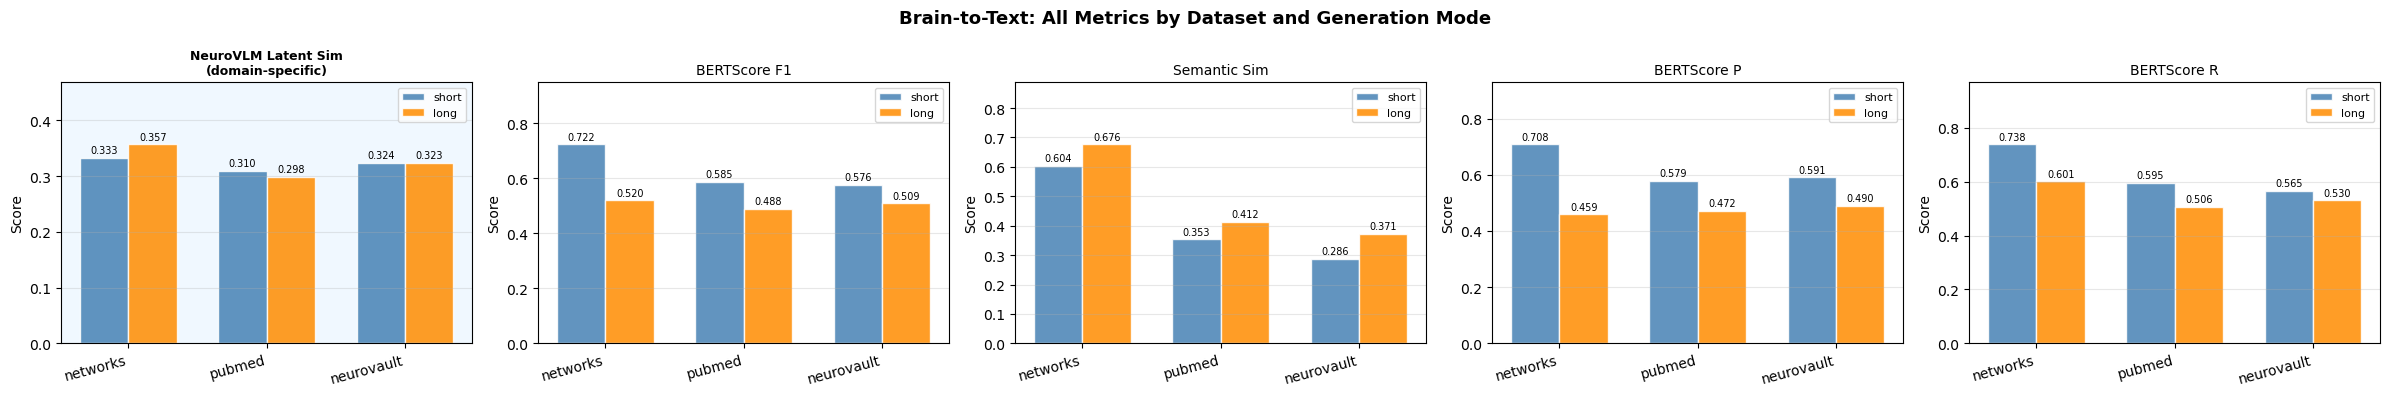

In [18]:
datasets  = ["networks", "pubmed", "neurovault"]
modes     = ["short", "long"]
metrics   = ["nvlm_sim", "bert_f1", "sem_sim", "bert_p", "bert_r"]
m_labels  = ["NeuroVLM Latent Sim", "BERTScore F1", "Semantic Sim",
             "BERTScore P", "BERTScore R"]

fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=False)
x      = np.arange(len(datasets))
w      = 0.35
colors = {"short": "steelblue", "long": "darkorange"}

for ax, metric, m_label in zip(axes, metrics, m_labels):
    for j, mode in enumerate(modes):
        vals = [
            b2t_all[(b2t_all["dataset"] == ds) & (b2t_all["mode"] == mode)][metric].mean()
            for ds in datasets
        ]
        offset = (j - 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=mode,
                      color=colors[mode], alpha=0.85, edgecolor="white")
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=15, ha="right")
    ax.set_title(m_label, fontsize=10)
    ax.set_ylabel("Score")
    ax.set_ylim(0, min(1.05, max(0.1, ax.get_ylim()[1] * 1.25)))
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

# Highlight the NeuroVLM-specific axis
axes[0].set_facecolor("#f0f8ff")
axes[0].set_title("NeuroVLM Latent Sim\n(domain-specific)", fontsize=9, fontweight="bold")

fig.suptitle("Brain-to-Text: All Metrics by Dataset and Generation Mode",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("b2t_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

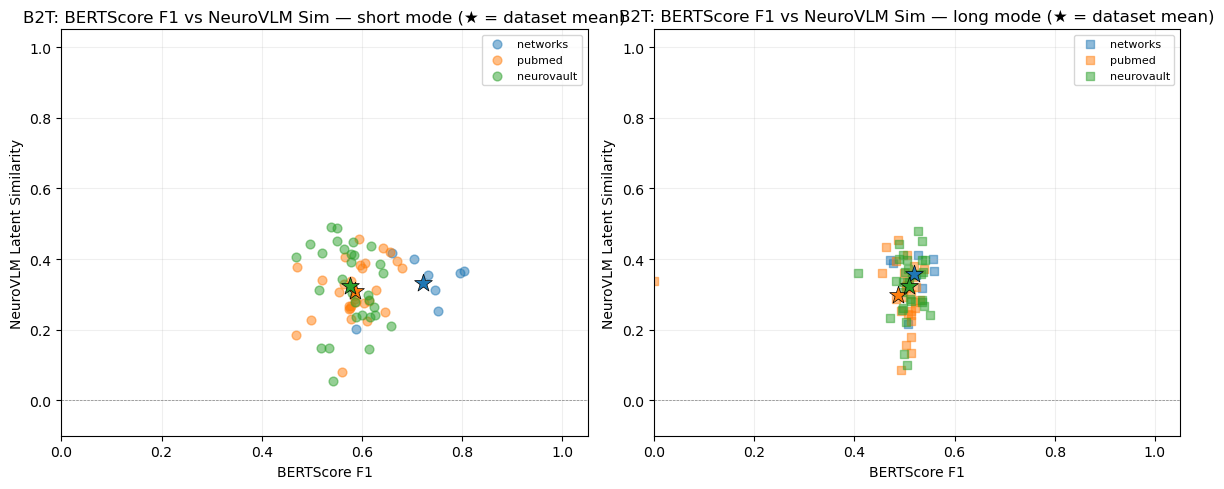

In [19]:
# NeuroVLM latent sim vs BERTScore F1 scatter — the domain-specific vs general-purpose comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ds_colors  = {"networks": "C0", "pubmed": "C1", "neurovault": "C2"}
ds_markers = {"short": "o", "long": "s"}

for ax, mode in zip(axes, modes):
    sub = b2t_all[b2t_all["mode"] == mode]
    for ds in datasets:
        rows = sub[sub["dataset"] == ds]
        ax.scatter(rows["bert_f1"], rows["nvlm_sim"],
                   s=40, alpha=0.5, color=ds_colors[ds], label=ds,
                   marker=ds_markers[mode])
        ax.scatter(rows["bert_f1"].mean(), rows["nvlm_sim"].mean(),
                   s=180, color=ds_colors[ds], marker="*", zorder=5,
                   edgecolors="black", linewidths=0.5)

    ax.set_xlim(0, 1.05)
    ax.set_ylim(-0.1, 1.05)
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.set_xlabel("BERTScore F1")
    ax.set_ylabel("NeuroVLM Latent Similarity")
    ax.set_title(f"B2T: BERTScore F1 vs NeuroVLM Sim — {mode} mode (★ = dataset mean)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.tight_layout()
plt.savefig("b2t_bertscore_vs_nvlm.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part B — Text-to-Brain (Pearson r, Spearman ρ, PSNR, Dice pct-90, Top-k overlap)

For each text input we:
1. Generate a predicted brain activation map via `nvlm.text(input).to_brain(head="mse")`.
2. Decode the ground-truth latent through the same autoencoder decoder.
3. Compare with improved spatial metrics.

**Improvements over v1:**
- **Percentile Dice** (pct=90): thresholds both maps at their own 90th-percentile activation
  rather than fixed absolute values, making it robust to intensity scale differences.
- **Spearman ρ**: rank-based correlation — does not assume linearity like Pearson.
- **Top-k voxel overlap**: fraction of predicted top-100 voxels that appear in ground-truth top-100.

In [ ]:
def _dice_percentile(pred: np.ndarray, true: np.ndarray, pct: int = 90) -> float:
    """Dice coefficient using percentile-based activation thresholding."""
    pred_bin = pred > np.percentile(pred, pct)
    true_bin = true > np.percentile(true, pct)
    intersection = (pred_bin & true_bin).sum()
    return 2.0 * intersection / (pred_bin.sum() + true_bin.sum() + 1e-8)


def _topk_overlap(pred: np.ndarray, true: np.ndarray, k: int = 100) -> float:
    """Fraction of top-k predicted voxels that are also top-k in ground truth."""
    top_pred = set(np.argsort(pred)[-k:])
    top_true = set(np.argsort(true)[-k:])
    return len(top_pred & top_true) / k


def run_t2b(name, text_input, true_latent):
    try:
        # --- Predicted brain map ------------------------------------------
        gen_result  = nvlm.text(text_input).to_brain(head="mse")
        nifti_pred  = gen_result.to_nifti(index=0)
        brain_pred  = masker.transform(nifti_pred).ravel().astype("float32")

        # --- Ground-truth map via same decoder ----------------------------
        dec        = gen_result.decoder
        dec_device = next(dec.parameters()).device
        lat        = true_latent
        if lat.dim() == 1:
            lat = lat.unsqueeze(0)
        with torch.no_grad():
            brain_true = (
                torch.sigmoid(dec(lat.to(dec_device)))
                .squeeze(0).cpu().numpy()
            )

        # --- Metrics ------------------------------------------------------
        pearson_r = float(pearson_correlation(brain_true, brain_pred))
        psnr_db   = float(psnr(brain_true, brain_pred, data_range=1.0))

        spearman_rho, _ = spearmanr(brain_true.ravel(), brain_pred.ravel())

        dice_p90 = _dice_percentile(brain_pred, brain_true, pct=DICE_PCT)
        topk     = _topk_overlap(brain_pred, brain_true, k=TOPK_K)

        return {
            "name":         name,
            "text_input":   text_input[:80],
            "pearson_r":    pearson_r,
            "spearman_rho": float(spearman_rho),
            "psnr_db":      psnr_db,
            "dice_pct90":   float(dice_p90),
            "topk_overlap": float(topk),
        }

    except Exception as e:
        print(f"  [T2B error] {name}: {e}")
        return None

### B.1 Networks

Text input = long network description.  
Ground truth = Du atlas network latent.

In [ ]:
t2b_networks_records = []

for net_name, d in tqdm(networks_data.items(), desc="Networks T2B"):
    rec = run_t2b(
        name        = net_name,
        text_input  = d["long_gt"],
        true_latent = d["latent"],
    )
    if rec is not None:
        t2b_networks_records.append(rec)

t2b_net_df = pd.DataFrame(t2b_networks_records).set_index("name")

display_cols = ["pearson_r", "spearman_rho", "psnr_db", "dice_pct90", "topk_overlap"]
t2b_net_df[display_cols].round(3)

Networks T2B:   0%|          | 0/8 [00:00<?, ?it/s]

,pearson_r,spearman_rho,psnr_db,dice_pct90,topk_overlap
name,,,,,
Language,0.537,0.581,20.010,0.527,0.17
Auditory,0.646,0.539,24.931,0.720,0.40
Default Mode,0.499,0.565,21.839,0.437,0.50
Frontoparietal Control,0.580,0.752,23.030,0.618,0.28
Attention,0.433,0.647,21.584,0.503,0.08
Visual,0.461,0.486,20.545,0.724,0.02
Motor,0.553,0.749,20.619,0.725,0.12
Cingulo-Opercular,0.359,0.587,20.024,0.354,0.00


### B.2 PubMed

Text input = title + " [SEP] " + abstract.  
Ground truth = pre-encoded PubMed brain image latent.

In [ ]:
t2b_pubmed_records = []

for d in tqdm(pubmed_data_t2b, desc="PubMed T2B"):
    text_in = d["short_gt"] + " [SEP] " + d["long_gt"]
    rec = run_t2b(
        name        = str(d["pmid"]),
        text_input  = text_in,
        true_latent = d["latent"],
    )
    if rec is not None:
        t2b_pubmed_records.append(rec)

t2b_pubmed_df = pd.DataFrame(t2b_pubmed_records)

print(f"PubMed T2B — {len(t2b_pubmed_df)} samples evaluated")
t2b_pubmed_df[["pearson_r", "spearman_rho", "psnr_db", "dice_pct90", "topk_overlap"]].describe().round(3)

PubMed T2B:   0%|          | 0/50 [00:00<?, ?it/s]

PubMed T2B — 50 samples evaluated


,pearson_r,spearman_rho,psnr_db,dice_pct90,topk_overlap
count,50.000,50.000,50.000,50.000,50.000
mean,0.393,0.530,26.903,0.375,0.157
std,0.192,0.190,2.784,0.145,0.176
min,-0.046,-0.027,20.636,0.006,0.000
25%,0.261,0.387,25.680,0.267,0.000
50%,0.405,0.550,27.236,0.396,0.080
75%,0.549,0.682,28.845,0.475,0.230
max,0.713,0.819,32.049,0.604,0.620


### B.3 NeuroVault

Text input = title + " [SEP] " + abstract.  
Ground truth = pre-encoded NeuroVault brain image latent.

In [ ]:
t2b_nv_records = []

for d in tqdm(neurovault_data_t2b, desc="NeuroVault T2B"):
    text_in = d["short_gt"] + " [SEP] " + d["long_gt"]
    rec = run_t2b(
        name        = str(d["doi"]),
        text_input  = text_in,
        true_latent = d["latent"],
    )
    if rec is not None:
        t2b_nv_records.append(rec)

t2b_nv_df = pd.DataFrame(t2b_nv_records)

print(f"NeuroVault T2B — {len(t2b_nv_df)} samples evaluated")
t2b_nv_df[["pearson_r", "spearman_rho", "psnr_db", "dice_pct90", "topk_overlap"]].describe().round(3)

NeuroVault T2B:   0%|          | 0/50 [00:00<?, ?it/s]

NeuroVault T2B — 50 samples evaluated


,pearson_r,spearman_rho,psnr_db,dice_pct90,topk_overlap
count,50.000,50.000,50.000,50.000,50.000
mean,0.152,0.377,22.799,0.212,0.024
std,0.161,0.213,3.371,0.161,0.056
min,-0.096,-0.128,16.462,0.000,0.000
25%,0.032,0.216,20.129,0.089,0.000
50%,0.131,0.383,22.003,0.184,0.000
75%,0.250,0.549,24.883,0.319,0.008
max,0.517,0.708,32.047,0.591,0.240


### B.4 Text-to-Brain Summary

In [ ]:
t2b_net_df_flat = t2b_net_df.reset_index().rename(columns={"name": "sample"})
t2b_net_df_flat["dataset"] = "networks"
t2b_pubmed_df["dataset"]   = "pubmed"
t2b_nv_df["dataset"]       = "neurovault"

t2b_all = pd.concat(
    [t2b_net_df_flat, t2b_pubmed_df, t2b_nv_df],
    ignore_index=True
)

t2b_metric_cols = ["pearson_r", "spearman_rho", "psnr_db", "dice_pct90", "topk_overlap"]

summary_t2b = (
    t2b_all
    .groupby("dataset")[t2b_metric_cols]
    .agg(["mean", "std"])
    .round(3)
)

print("=== Text-to-Brain Summary (mean ± std) ===")
summary_t2b

=== Text-to-Brain Summary (mean ± std) ===


pearson_r        spearman_rho        psnr_db        dice_pct90  \
                mean    std         mean    std    mean    std       mean   
dataset                                                                     
networks       0.508  0.090        0.613  0.096  21.573  1.702      0.576   
neurovault     0.152  0.161        0.377  0.213  22.799  3.371      0.212   
pubmed         0.393  0.192        0.530  0.190  26.903  2.784      0.375   

                  topk_overlap         
              std         mean    std  
dataset                                
networks    0.143        0.196  0.181  
neurovault  0.161        0.024  0.056  
pubmed      0.145        0.157  0.176

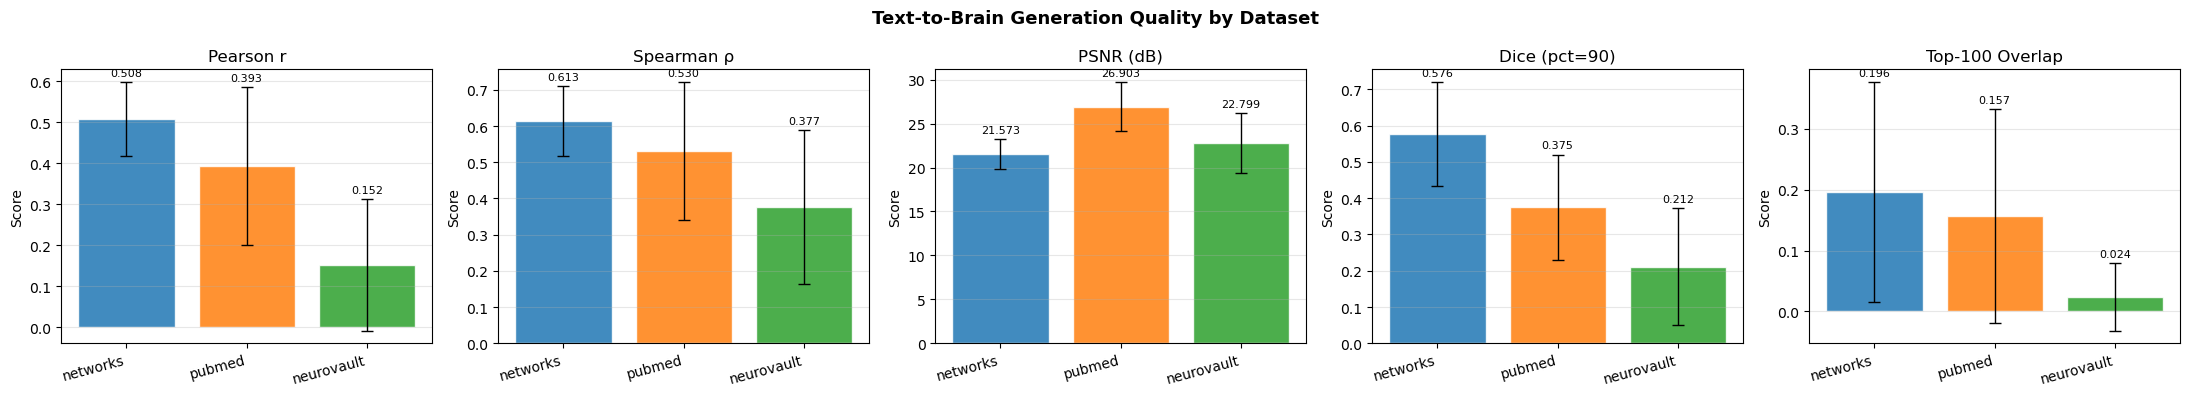

In [ ]:
ds_order   = ["networks", "pubmed", "neurovault"]
t2b_cols   = ["pearson_r", "spearman_rho", "psnr_db", "dice_pct90", "topk_overlap"]
t2b_labels = ["Pearson r", "Spearman ρ", "PSNR (dB)", f"Dice (pct={DICE_PCT})", f"Top-{TOPK_K} Overlap"]
ds_colors  = ["C0", "C1", "C2"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)
x = np.arange(len(ds_order))

for ax, metric, m_label in zip(axes, t2b_cols, t2b_labels):
    means = [t2b_all[t2b_all["dataset"] == ds][metric].mean() for ds in ds_order]
    stds  = [t2b_all[t2b_all["dataset"] == ds][metric].std()  for ds in ds_order]
    bars  = ax.bar(x, means, color=ds_colors, alpha=0.85, edgecolor="white",
                   yerr=stds, capsize=4, error_kw={"linewidth": 1})
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(ds_order, rotation=15, ha="right")
    ax.set_title(m_label)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Text-to-Brain Generation Quality by Dataset",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("t2b_metrics_v2.png", dpi=150, bbox_inches="tight")
plt.show()

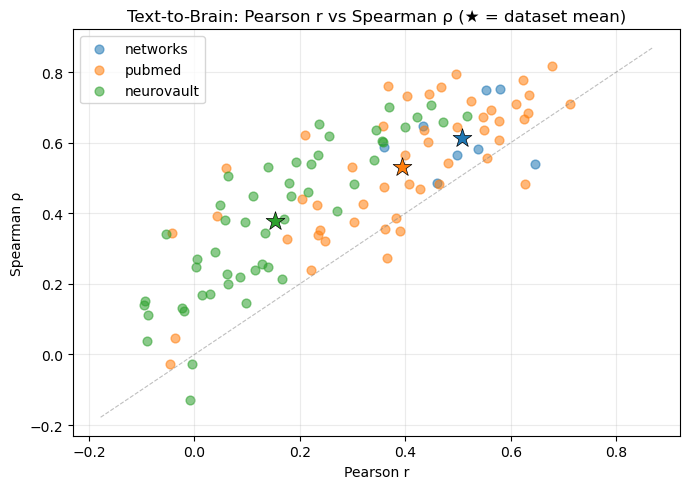

In [ ]:
# Pearson r vs Spearman ρ scatter — coloured by dataset
fig, ax = plt.subplots(figsize=(7, 5))

for ds, c in zip(ds_order, ds_colors):
    sub = t2b_all[t2b_all["dataset"] == ds]
    ax.scatter(sub["pearson_r"], sub["spearman_rho"],
               s=40, alpha=0.55, color=c, label=ds)
    ax.scatter(sub["pearson_r"].mean(), sub["spearman_rho"].mean(),
               s=200, color=c, marker="*", zorder=5,
               edgecolors="black", linewidths=0.5)

lim_min = min(t2b_all[["pearson_r", "spearman_rho"]].min()) - 0.05
lim_max = max(t2b_all[["pearson_r", "spearman_rho"]].max()) + 0.05
ax.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="grey", lw=0.8, alpha=0.5)

ax.set_xlabel("Pearson r")
ax.set_ylabel("Spearman ρ")
ax.set_title("Text-to-Brain: Pearson r vs Spearman ρ (★ = dataset mean)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig("t2b_pearson_vs_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Full Evaluation Summary

In [ ]:
print("\n" + "="*65)
print("BRAIN-TO-TEXT  (mean across samples)")
print("="*65)
print(
    b2t_all
    .groupby(["dataset", "mode"])[["nvlm_sim", "bert_f1", "sem_sim"]]
    .mean()
    .round(4)
    .to_string()
)

print("\n" + "="*65)
print("TEXT-TO-BRAIN  (spatial metrics mean across samples)")
print("="*65)
print(
    t2b_all
    .groupby("dataset")[["pearson_r", "spearman_rho", "psnr_db", "dice_pct90", "topk_overlap"]]
    .mean()
    .round(4)
    .to_string()
)


BRAIN-TO-TEXT  (mean across samples)
                  nvlm_sim  bert_f1  sem_sim  meteor
dataset    mode                                     
networks   long     0.3465   0.5125   0.6753  0.0971
           short    0.3057   0.7144   0.5472  0.2313
neurovault long     0.3296   0.5101   0.3735  0.1558
           short    0.3365   0.5777   0.2836  0.0263
pubmed     long     0.2952   0.4798   0.4116  0.1646
           short    0.2970   0.5826   0.3183  0.0404

TEXT-TO-BRAIN  (spatial metrics mean across samples)
            pearson_r  spearman_rho  psnr_db  dice_pct90  topk_overlap
dataset                                                               
networks       0.5084        0.6134  21.5727      0.5762        0.1962
neurovault     0.1521        0.3768  22.7990      0.2117        0.0238
pubmed         0.3931        0.5302  26.9027      0.3754        0.1566
